# Factory Insight AI - LightGBM and Cross Validation

## 1. 目的

前フェーズではRandomForestに派生特徴量を追加することで、
故障予測性能を大きく改善できた。

一方、これまでの判定閾値は単一のValidation分割を用いて決定しており、
特定のデータ分割に結果が依存している可能性がある。

本NotebookではStratifiedKFoldによる5-Fold Cross Validationを導入し、
モデル性能の安定性を検証する。

さらにLightGBMを構築し、
各Foldの予測からOOF（Out-of-Fold）予測を作成する。

OOF予測を用いてTestデータとは独立に判定閾値を決定し、
最終的にRandomForestとの性能を比較する。

## 2. データ読み込み

In [1]:
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("../data/raw/ai4i2020.csv")

df = pd.read_csv(DATA_PATH)

df.shape

(10000, 14)

## 3. 派生特徴量

In [2]:
df_featured = df.copy()

df_featured["Power [W]"] = (
    2
    * np.pi
    * df_featured["Rotational speed [rpm]"]
    * df_featured["Torque [Nm]"]
    / 60
)

df_featured["Wear-Torque"] = (
    df_featured["Tool wear [min]"]
    * df_featured["Torque [Nm]"]
)

df_featured["Temperature difference [K]"] = (
    df_featured["Process temperature [K]"]
    - df_featured["Air temperature [K]"]
)

## 4. 特徴量と目的変数

In [3]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Power [W]",
    "Wear-Torque",
    "Temperature difference [K]",
]

categorical_features = [
    "Type",
]

target = "Machine failure"

X = df_featured[
    numeric_features + categorical_features
]

y = df_featured[target]

X.shape, y.shape

((10000, 9), (10000,))

## 5. Train / Test分割

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print()
print("Train failure rate:", y_train.mean())
print("Test failure rate:", y_test.mean())

Train: (8000, 9)
Test: (2000, 9)

Train failure rate: 0.033875
Test failure rate: 0.034


## 6. 交差検証の設計

In [5]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

## 7. LightGBM 5-Fold Cross Validation

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
    ]
)

In [7]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)

oof_proba = np.zeros(len(X_train))

fold_results = []

In [8]:
for fold, (train_idx, valid_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1,
):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_valid = X_train.iloc[valid_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_valid = y_train.iloc[valid_idx]

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                LGBMClassifier(
                    n_estimators=300,
                    learning_rate=0.05,
                    num_leaves=31,
                    random_state=42,
                    n_jobs=-1,
                    verbosity=-1,
                ),
            ),
        ]
    )

    model.fit(
        X_fold_train,
        y_fold_train,
    )

    fold_proba = model.predict_proba(
        X_fold_valid
    )[:, 1]

    oof_proba[valid_idx] = fold_proba

    fold_roc_auc = roc_auc_score(
        y_fold_valid,
        fold_proba,
    )

    fold_ap = average_precision_score(
        y_fold_valid,
        fold_proba,
    )

    fold_results.append(
        {
            "fold": fold,
            "ROC-AUC": fold_roc_auc,
            "Average Precision": fold_ap,
        }
    )

    print(
        f"Fold {fold}: "
        f"ROC-AUC={fold_roc_auc:.4f}, "
        f"AP={fold_ap:.4f}"
    )

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: ROC-AUC=0.9820, AP=0.9139


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: ROC-AUC=0.9785, AP=0.8333


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 3: ROC-AUC=0.9581, AP=0.8762


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4: ROC-AUC=0.9798, AP=0.8690
Fold 5: ROC-AUC=0.9725, AP=0.8940


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [9]:
fold_results_df = pd.DataFrame(fold_results)

fold_results_df

,fold,ROC-AUC,Average Precision
0,1,0.982044,0.913871
1,2,0.978475,0.833271
2,3,0.958100,0.876193
3,4,0.979793,0.868999
4,5,0.972498,0.894044


In [10]:
fold_summary = fold_results_df[
    [
        "ROC-AUC",
        "Average Precision",
    ]
].agg(
    ["mean", "std"]
)

fold_summary

,ROC-AUC,Average Precision
mean,0.974182,0.877275
std,0.009659,0.030110


## 8. OOF評価

In [11]:
oof_roc_auc = roc_auc_score(
    y_train,
    oof_proba,
)

oof_ap = average_precision_score(
    y_train,
    oof_proba,
)

print(
    f"OOF ROC-AUC: {oof_roc_auc:.4f}"
)

print(
    f"OOF Average Precision: {oof_ap:.4f}"
)

OOF ROC-AUC: 0.9739
OOF Average Precision: 0.8754


## 9. OOFによる閾値最適化

In [12]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
)

In [13]:
thresholds = np.linspace(
    0.01,
    0.50,
    100,
)

oof_threshold_results = []

for threshold in thresholds:
    oof_pred = (
        oof_proba >= threshold
    ).astype(int)

    oof_threshold_results.append(
        {
            "threshold": threshold,
            "precision": precision_score(
                y_train,
                oof_pred,
                zero_division=0,
            ),
            "recall": recall_score(
                y_train,
                oof_pred,
                zero_division=0,
            ),
            "f1": f1_score(
                y_train,
                oof_pred,
                zero_division=0,
            ),
        }
    )

oof_threshold_results = pd.DataFrame(
    oof_threshold_results
)

oof_threshold_results.head()

,threshold,precision,recall,f1
0,0.010000,0.742671,0.841328,0.788927
1,0.014949,0.770270,0.841328,0.804233
2,0.019899,0.791667,0.841328,0.815742
3,0.024848,0.799296,0.837638,0.818018
4,0.029798,0.801418,0.833948,0.817360


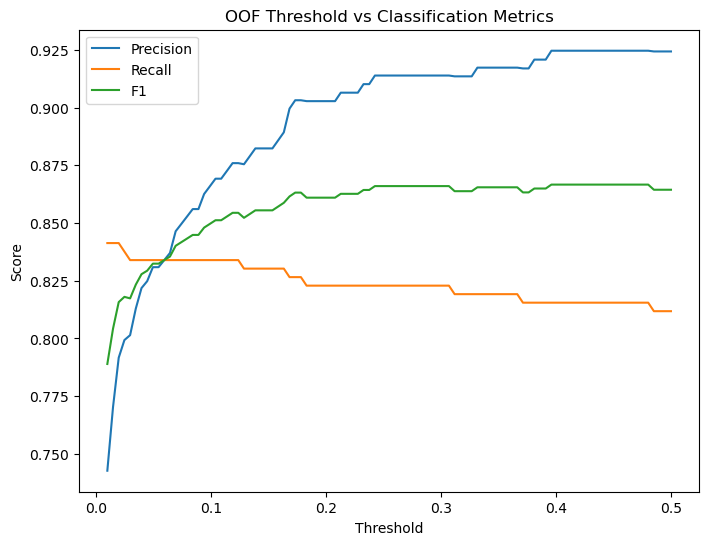

In [14]:
plt.figure(figsize=(8, 6))

plt.plot(
    oof_threshold_results["threshold"],
    oof_threshold_results["precision"],
    label="Precision",
)

plt.plot(
    oof_threshold_results["threshold"],
    oof_threshold_results["recall"],
    label="Recall",
)

plt.plot(
    oof_threshold_results["threshold"],
    oof_threshold_results["f1"],
    label="F1",
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("OOF Threshold vs Classification Metrics")
plt.legend()
plt.show()

In [15]:
oof_threshold_candidates = (
    oof_threshold_results[
        oof_threshold_results["recall"] >= 0.80
    ]
    .copy()
)

oof_threshold_candidates.sort_values(
    ["precision", "threshold"],
    ascending=[False, False],
).head(10)

,threshold,precision,recall,f1
95,0.480202,0.924686,0.815498,0.866667
94,0.475253,0.924686,0.815498,0.866667
93,0.470303,0.924686,0.815498,0.866667
92,0.465354,0.924686,0.815498,0.866667
91,0.460404,0.924686,0.815498,0.866667
90,0.455455,0.924686,0.815498,0.866667
89,0.450505,0.924686,0.815498,0.866667
88,0.445556,0.924686,0.815498,0.866667
87,0.440606,0.924686,0.815498,0.866667
86,0.435657,0.924686,0.815498,0.866667


In [16]:
best_oof_recall80_row = (
    oof_threshold_candidates
    .sort_values(
        ["precision", "threshold"],
        ascending=[False, False],
    )
    .iloc[0]
)

best_oof_recall80_row

threshold    0.480202
precision    0.924686
recall       0.815498
f1           0.866667
Name: 95, dtype: float64

In [17]:
best_oof_f1_row = (
    oof_threshold_results.loc[
        oof_threshold_results["f1"].idxmax()
    ]
)

best_oof_f1_row

threshold    0.396061
precision    0.924686
recall       0.815498
f1           0.866667
Name: 78, dtype: float64

In [18]:
from sklearn.metrics import confusion_matrix

selected_oof_threshold = (
    best_oof_recall80_row["threshold"]
)

oof_selected_pred = (
    oof_proba >= selected_oof_threshold
).astype(int)

oof_cm = confusion_matrix(
    y_train,
    oof_selected_pred,
)

oof_cm

array([[7711,   18],
       [  50,  221]])

### Cross Validationの結果

5-Fold Stratified Cross Validationを実施した結果、
ROC-AUCの平均は0.974、標準偏差は0.010となった。

Average Precisionの平均は0.877、
標準偏差は0.030となった。

また、Trainデータ8,000件すべてについて作成した
OOF予測では、ROC-AUC 0.974、
Average Precision 0.875となった。

各FoldでROC-AUCおよびAverage Precisionが高い水準を維持しており、
単一のValidation分割だけではなく、
異なるデータ分割でもLightGBMが安定した
故障識別性能を示すことが確認できた。

次に、Testデータを使用せず、
OOF予測を用いて判定閾値を決定する。

### OOFによる判定閾値の選択

Trainデータ8,000件について作成したOOF予測を用いて、
判定閾値を0.01から0.50まで探索した。

本プロジェクトでは故障の見逃しを重視するため、
これまでと同様にRecall 0.80以上を満たす候補の中から
Precisionが最大となる閾値を選択した。

その結果、閾値約0.480で
Precision 0.925、Recall 0.815、F1 0.867となった。

OOF予測のConfusion Matrixでは、
故障271件のうち221件を検出し、50件を見逃した。
また、正常7,729件のうち誤って故障と判定したのは18件だった。

F1が最大となる閾値は約0.396だったが、
Precision 0.925、Recall 0.815、F1 0.867と
分類結果は選択した閾値と同一だった。

以上から、事前に設定したRecall 0.80以上という条件を満たしながら、
高いPrecisionを確保できた約0.480を
LightGBMの最終判定閾値として採用する。

この閾値はTestデータを使用せず、
TrainデータのOOF予測のみから決定した。

## 10. 最終LightGBM

In [19]:
selected_threshold = best_oof_recall80_row["threshold"]

selected_threshold

np.float64(0.4802020202020202)

In [20]:
final_lgbm_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.05,
                num_leaves=31,
                random_state=42,
                n_jobs=-1,
                verbosity=-1,
            ),
        ),
    ]
)

In [21]:
final_lgbm_model.fit(
    X_train,
    y_train,
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]',
                                                   'Power [W]', 'Wear-Torque',
                                                   'Temperature difference '
                                                   '[K]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Type'])])),
                ('classifier',
                 LGBMClassifier(learning_rate=0.05, n_estimators=300, n_jobs=-1,
                                random_state=42, verbosity=-1))])

In [22]:
test_proba = final_lgbm_model.predict_proba(
    X_test
)[:, 1]

test_pred = (
    test_proba >= selected_threshold
).astype(int)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [23]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


def evaluate_model(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            y_proba,
        ),
        "Average Precision": average_precision_score(
            y_true,
            y_proba,
        ),
    }

In [24]:
lgbm_test_metrics = evaluate_model(
    y_test,
    test_pred,
    test_proba,
)

pd.Series(lgbm_test_metrics)

Accuracy             0.992500
Precision            0.949153
Recall               0.823529
F1                   0.881890
ROC-AUC              0.981953
Average Precision    0.891839
dtype: float64

In [25]:
lgbm_test_cm = confusion_matrix(
    y_test,
    test_pred,
)

lgbm_test_cm

array([[1929,    3],
       [  12,   56]])

### Testデータによる最終評価

OOF予測から決定した閾値約0.480を固定し、
Trainデータ8,000件すべてでLightGBMを再学習した後、
Testデータ2,000件で最終評価を行った。

その結果、Precision 0.949、Recall 0.824、
F1 0.882、ROC-AUC 0.982、
Average Precision 0.892となった。

Confusion Matrixでは、実際の故障68件のうち56件を検出し、
12件を見逃した。

一方、正常設備1,932件のうち、
故障と誤判定した設備は3件だった。

Testデータを用いて閾値を再調整することなく、
事前に設定したRecall 0.80以上という目標を維持できた。

また、OOF評価とTest評価の性能にも大きな乖離がなく、
交差検証で確認した性能が未知データでも概ね維持された。

## 11. RandomForestとの比較

In [26]:
final_model_comparison = pd.DataFrame(
    {
        "RandomForest + Derived Features": {
            "Accuracy": 0.990000,
            "Precision": 0.863636,
            "Recall": 0.838235,
            "F1": 0.850746,
            "ROC-AUC": 0.979601,
            "Average Precision": 0.893332,
        },
        "LightGBM + Derived Features": lgbm_test_metrics,
    }
).T

final_model_comparison

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
RandomForest + Derived Features,0.9900,0.863636,0.838235,0.850746,0.979601,0.893332
LightGBM + Derived Features,0.9925,0.949153,0.823529,0.881890,0.981953,0.891839


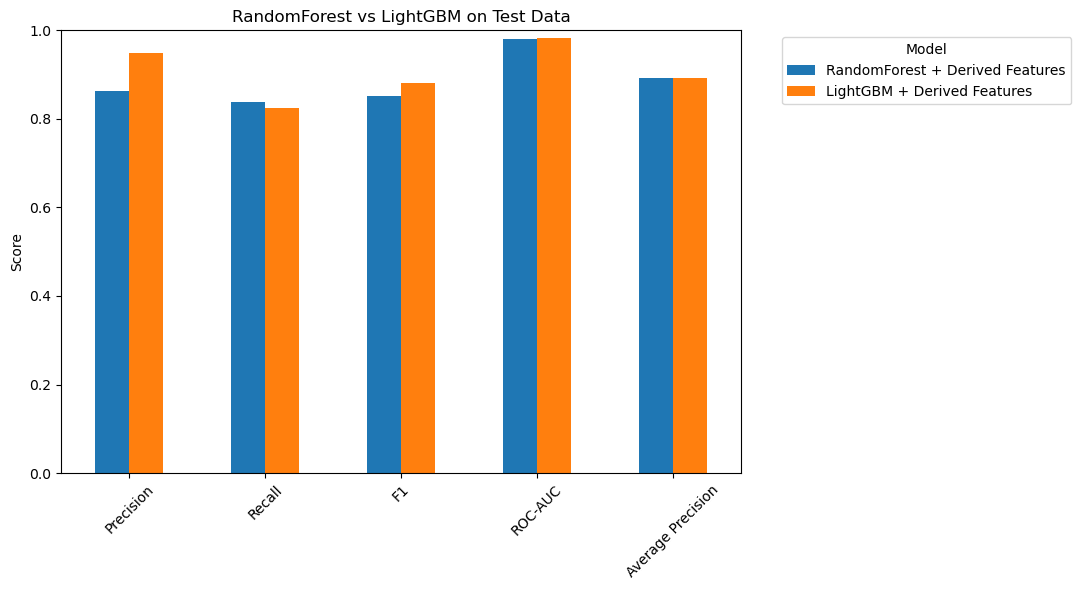

In [27]:
metrics_to_plot = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "Average Precision",
]

final_model_comparison[
    metrics_to_plot
].T.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("RandomForest vs LightGBM on Test Data")
plt.xticks(rotation=45)
plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

派生特徴量を使用したRandomForestとLightGBMを
同じTestデータで比較した。

LightGBMではPrecisionが0.864から0.949、
F1が0.851から0.882へ向上した。

一方、RecallはRandomForestの0.838に対して
LightGBMでは0.824となり、わずかに低下した。

Average Precisionについても、
RandomForestの0.893に対してLightGBMは0.892となり、
ほぼ同等だった。

Confusion Matrixでは、
RandomForestが故障57件を検出して11件を見逃したのに対し、
LightGBMでは56件を検出して12件を見逃した。

一方、False PositiveはRandomForestの9件から
LightGBMでは3件まで減少した。

したがってLightGBMは、
RandomForestより故障を1件多く見逃す代わりに、
誤警報を6件削減する結果となった。

両モデルともRecall 0.80以上という目標を満たしているが、
故障の見逃しと不要な点検のどちらを重視するかによって、
最適なモデルは異なると考えられる。

## 12. 考察

### 交差検証による安定性

LightGBMに対して5-Fold Stratified Cross Validationを実施した結果、
ROC-AUCは平均0.974、標準偏差0.010、
Average Precisionは平均0.877、標準偏差0.030となった。

また、OOF全体でもROC-AUC 0.974、
Average Precision 0.875となった。

各Foldで大きな性能低下は見られず、
単一のValidation分割だけではなく、
異なるデータ分割でも比較的安定した性能を示した。

### OOFによる閾値決定

OOF予測を用いて、
Recall 0.80以上を満たす候補の中から
Precisionが最大となる判定閾値を選択した。

その結果、約0.480の閾値で
Precision 0.925、Recall 0.815、
F1 0.867となった。

Testデータを使用せずに判定閾値を決定したことで、
Testデータに合わせて閾値を調整することを避けた。

さらに、固定した閾値をTestデータに適用した結果でも
Recall 0.824となり、
事前に設定したRecall 0.80以上という目標を維持できた。

### RandomForestとLightGBMの比較

派生特徴量を使用したRandomForestと比較すると、
LightGBMではPrecisionが0.864から0.949、
F1が0.851から0.882へ向上した。

一方、Recallは0.838から0.824へわずかに低下し、
Average Precisionも0.893から0.892とほぼ同等だった。

実際の判定件数を見ると、
RandomForestでは故障を11件見逃し、誤警報が9件だった。

LightGBMでは故障の見逃しが12件となった一方、
誤警報は3件まで減少した。

つまりLightGBMはRandomForestと比較して
故障を1件多く見逃す代わりに、
誤警報を6件削減する結果となった。

### 最終候補モデル

本プロジェクトでは、
故障の見逃しを抑えるためRecall 0.80以上を
最低条件として設定している。

RandomForestとLightGBMはいずれもこの条件を満たした。

そのうえでLightGBMは、
RandomForestよりPrecisionとF1が高く、
誤警報も9件から3件まで減少した。

そのため、現時点では
LightGBMを最終候補モデルとして採用する。

ただし、実際の製造現場では、
故障を1件見逃した場合の損失と
不要な点検を1件行った場合のコストは同じではない。

実運用ではこれらのコストを定量化し、
業務上の損失を最小化するように
モデルや判定閾値を決定する必要がある。

## 13. 次のステップ

LightGBMと5-Fold Cross Validationを導入することで、
モデル性能の安定性を確認しながら、
Testデータを使用せずにOOF予測から
判定閾値を決定できた。

また、RandomForestとの比較から、
現時点ではLightGBMを最終候補モデルとして採用する。

次のフェーズでは、
モデルの予測根拠を説明できるようにするため、
SHAPを用いたモデル解釈を行う。

具体的には以下を実施する。

1. LightGBMの特徴量重要度を確認する。
2. SHAPを用いて各特徴量が故障予測に与える影響を分析する。
3. SHAP Summary Plotでモデル全体の傾向を可視化する。
4. 個別設備について故障リスクが高くなった理由を可視化する。
5. 分析結果を保全担当者が理解できる形で整理する。

最終的には、
単に「故障確率が高い」と提示するだけではなく、
どのセンサー値や設備状態が故障リスクを高めているのかを示し、
保全対象設備の優先順位付けを支援できるモデルを目指す。